# g-and-k Ablations Notebook

This notebook is the notebook version of the g-and-k ablation plots, adapted to this repo layout. It reads saved ablation `.npz` files from `ablations/`, renders figures inline, and saves the main ablation figures to `figures/`.


In [283]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
ABLATIONS_DIR = ROOT / "ablations"
RESULTS_DIR = ROOT / "results" / "gnk"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

STEP_OUTPUT = FIGURES_DIR / "gk_step_size_ablation.pdf"
DECAY_OUTPUT = FIGURES_DIR / "gk_decay_ablation.pdf"
MN_OUTPUT = FIGURES_DIR / "gk_mn_theta_error_boxplots.pdf"
LENGTHSCALE_OUTPUT = FIGURES_DIR / "gk_lengthscale_ridge_ablation.pdf"

FIGSIZE = (6, 4)
SUMMARY_DPI = 150
TITLE_SIZE = 28
LABEL_SIZE = 26
TICK_SIZE = 22
LEGEND_SIZE = 20
MARKER_SIZE = 5
LINE_WIDTH = 2.0
COLORS = {
    "sgd": "#7570b3",
    "natural": "#1b9e77",
    "pgd": "#d95f02",
}
BOX_COLORS = [
    "#4c78a8",
    "#e45756",
    "#72b7b2",
    "#b279a2",
    "#ff9da6",
    "#9d755d",
    "#bab0ab",
]

BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.frameon": False,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "lines.linewidth": LINE_WIDTH,
    "lines.markersize": MARKER_SIZE,
    "figure.figsize": FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)


def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _make_single_color_boxplot(ax, series, labels, color, xlabel, ylabel, title=None, logy=True):
    bp = ax.boxplot(series, patch_artist=True, widths=0.6)
    palette = BOX_COLORS
    for idx, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(palette[idx % len(palette)])
        patch.set_alpha(0.8)
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2.0)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)
    if logy:
        ax.set_yscale("log")
    return bp


def _theta_error_series_gk(npz_path):
    data = _load_npz_dict(npz_path)
    theta_true = np.asarray(data["theta_true"], dtype=float)
    theta_finals = np.asarray(data["adaptive_thetas"], dtype=float)
    return np.linalg.norm(theta_finals - theta_true[None, :], axis=1)


def make_gk_step_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_step_size_ablation_gamma_pgd0_sweep_(?P<gamma>[^/]+)/")
    collected = []
    for npz_path in sorted(results_dir.rglob("g_n_k_fixed*.npz")):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        gamma = float(match.group("gamma").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((gamma, _theta_error_series_gk(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{gamma:g}" for gamma, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Stepsize," r" $\gamma$", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_decay_boxplot(results_dir, output_path=None):
    pattern = re.compile(r"g_and_k_decay_ablation_decay_sweep_(?P<decay>[^/]+)/")
    collected = []
    for npz_path in sorted(results_dir.rglob("g_n_k_fixed*.npz")):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        decay = float(match.group("decay").replace("p", ".").replace("m", "-"))
        data = _load_npz_dict(npz_path)
        collected.append((decay, _theta_error_series_gk(npz_path)))
    collected.sort(key=lambda item: item[0])
    labels = [f"{decay:g}" for decay, _ in collected]
    series = [values for _, values in collected]
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=SUMMARY_DPI)
        _make_single_color_boxplot(ax, series, labels, COLORS["pgd"], "Decay rate", r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _collect_gk_mn_theta_errors(results_dir):
    pattern = re.compile(r"g_and_k_observation_model_grid_m_(?P<m>[^_]+)_n_(?P<n>[^/]+)/")
    by_mn = {}
    m_values = set()
    n_values = set()
    for npz_path in sorted(results_dir.rglob("g_n_k_fixed*.npz")):
        match = pattern.search(npz_path.as_posix())
        if match is None:
            continue
        m = float(match.group("m").replace("p", ".").replace("m", "-"))
        n = float(match.group("n").replace("p", ".").replace("m", "-"))
        by_mn[(m, n)] = _theta_error_series_gk(npz_path)
        m_values.add(m)
        n_values.add(n)
    return by_mn, sorted(m_values), sorted(n_values)


def make_gk_mn_boxplots(results_dir, output_path=None):
    by_mn, m_values, n_values = _collect_gk_mn_theta_errors(results_dir)
    grouped_by_n = [np.concatenate([by_mn[(m, n)] for m in m_values]) for n in n_values]
    grouped_by_m = [np.concatenate([by_mn[(m, n)] for n in n_values]) for m in m_values]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4), dpi=SUMMARY_DPI, gridspec_kw={"wspace": 0.38})
        _make_single_color_boxplot(
            axes[0],
            grouped_by_n,
            [f"{n:g}" for n in n_values],
            "#4c78a8",
            r"Model samples, $n$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by n",
            logy=True,
        )
        _make_single_color_boxplot(
            axes[1],
            grouped_by_m,
            [f"{m:g}" for m in m_values],
            "#f58518",
            r"Observation samples, $m$",
            r"$\Vert\theta_{\mathrm{final}} - \theta_{\mathrm{true}}\Vert_2$",
            # title="PGD grouped by m",
            logy=True,
        )
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_lengthscale_ridge_heatmap(summary_path, output_path=None):
    summary = _load_npz_dict(summary_path)
    ell_values = np.asarray(summary["lengthscale_values"], dtype=float)
    lambda_values = np.asarray(summary["lambda_scales"], dtype=float)
    theta_mean_grid = np.asarray(summary["adaptive_theta_mean_grid"], dtype=float)
    output_paths = np.asarray(summary["output_paths"], dtype=object)

    sample_result = _load_npz_dict(Path(str(output_paths[0, 0])))
    theta_true = np.asarray(sample_result["theta_true"], dtype=float)
    error_grid = np.linalg.norm(theta_mean_grid - theta_true[None, None, :], axis=2)

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.0, 5.0), dpi=SUMMARY_DPI)
        im = ax.imshow(error_grid, cmap="viridis", aspect="auto")
        ax.set_xticks(np.arange(len(ell_values)))
        ax.set_yticks(np.arange(len(lambda_values)))
        ax.set_xticklabels([f"{value:g}" for value in ell_values])
        ax.set_yticklabels([f"{value:g}" for value in lambda_values])
        ax.set_xlabel(r"$\ell_{\infty}$")
        ax.set_ylabel(r"$\lambda$")
        ax.grid(False)
        for i in range(error_grid.shape[0]):
            for j in range(error_grid.shape[1]):
                if np.isfinite(error_grid[i, j]):
                    ax.text(j, i, f"{error_grid[i, j]:.2e}", ha="center", va="center", color="white", fontsize=12)
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r"$\|\bar{\theta}_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$", rotation=270, labelpad=30)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_gk_cross_method_comparison(npz_path, output_path=None):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "baseline_theta_histories",
        "adaptive_sgd_theta_histories",
        "adaptive_theta_histories",
        "fixed_pgd_theta_histories",
        "baseline_history_steps",
        "adaptive_sgd_history_steps",
        "adaptive_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for G-and-K cross-method comparison: " + ", ".join(missing))

    theta_true = np.asarray(data["theta_true"], dtype=float)

    def theta_err(histories_key):
        histories = np.asarray(data[histories_key], dtype=float)
        return np.linalg.norm(histories - theta_true[None, None, :], axis=-1)

    baseline_err = theta_err("baseline_theta_histories")
    adaptive_sgd_err = theta_err("adaptive_sgd_theta_histories")
    pgd_err = theta_err("adaptive_theta_histories")
    fixed_pgd_err = theta_err("fixed_pgd_theta_histories")

    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)
        ax.plot(baseline_steps, np.mean(baseline_err, axis=0), color=COLORS["sgd"], label="SGD fixed $\ell$")
        ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color="#4c78a8", label="SGD adaptive $\ell$")
        ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=COLORS["pgd"], label="PGD adaptive $\ell$")
        ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color="#ff9da6", label="PGD fixed $\ell$")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        ax.set_title("Cross-method comparison")
        ax.legend(loc="best")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


## Local file setup

These defaults match the saved g-and-k ablation files that currently exist in this repo.


In [284]:
gk_step_dir = ABLATIONS_DIR / "gk_gamma"
gk_decay_dir = ABLATIONS_DIR / "gk_decay"
gk_mn_dir = ABLATIONS_DIR / "gk_mn_grid"
gk_lengthscale_summary = ABLATIONS_DIR / "gk_heatmap" / "g_and_k_lengthscale_regularization_grid_ell_min_summary.npz"
gk_compare_npz = ROOT / "g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz"

{
    "gk_step_dir": gk_step_dir,
    "gk_decay_dir": gk_decay_dir,
    "gk_mn_dir": gk_mn_dir,
    "gk_lengthscale_summary": gk_lengthscale_summary,
    "gk_compare_npz": gk_compare_npz,
    "outputs": [STEP_OUTPUT, DECAY_OUTPUT, MN_OUTPUT, LENGTHSCALE_OUTPUT],
}


{'gk_step_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma'),
 'gk_decay_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_decay'),
 'gk_mn_dir': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_mn_grid'),
 'gk_lengthscale_summary': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_heatmap/g_and_k_lengthscale_regularization_grid_ell_min_summary.npz'),
 'gk_compare_npz': PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
 'outputs': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_step_size_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_decay_ablation.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_mn_theta_error_boxplots.pdf'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_lengthscale_ridge_ablation.pdf')]}

In [285]:
available_inputs = {
    "gk_step_files": list(gk_step_dir.rglob("g_n_k_fixed*.npz")),
    "gk_decay_files": list(gk_decay_dir.rglob("g_n_k_fixed*.npz")),
    "gk_mn_files": list(gk_mn_dir.rglob("g_n_k_fixed*.npz")),
    "gk_lengthscale_summary": gk_lengthscale_summary.exists(),
    "gk_compare_npz": gk_compare_npz.exists(),
}
available_inputs


{'gk_step_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p3/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p03/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_100/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_0p1/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
  PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_gamma/g_and_k_step_size_ablation_gamma_pgd0_sweep_1/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz')],
 'gk_decay_files': [PosixPath('/Users/sophiakang/Documents/GitHub/MDF_AL/ablations/gk_decay/g_and_k_dec

Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_step_size_ablation.pdf


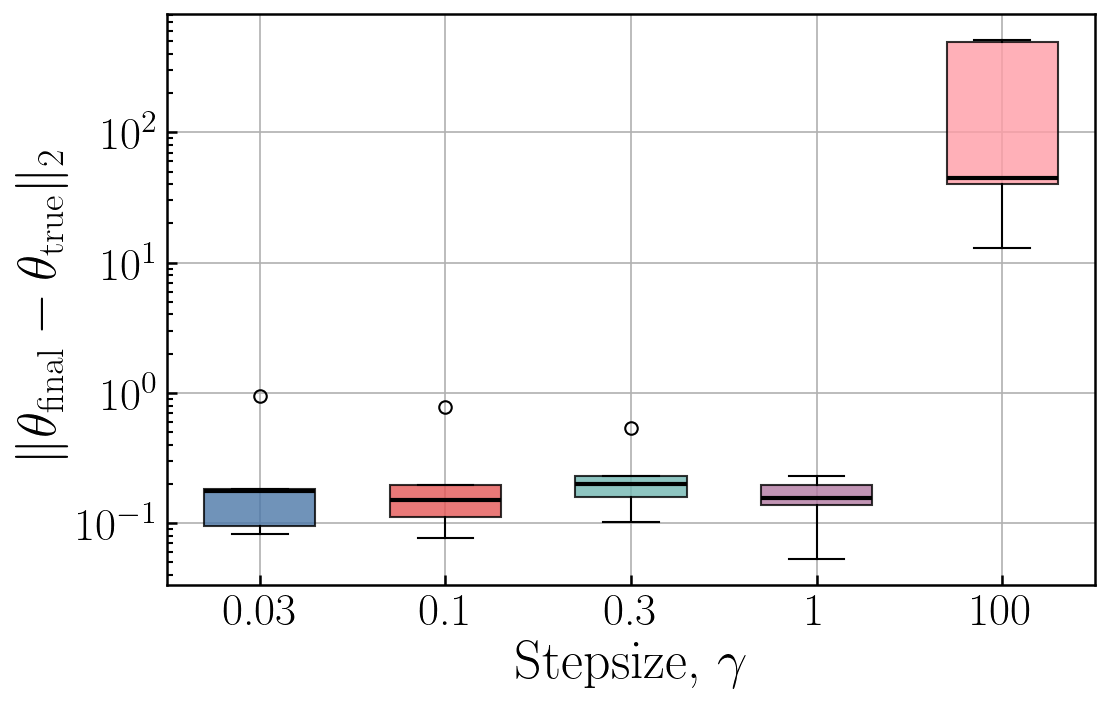

In [286]:
step_files = list(gk_step_dir.rglob("g_n_k_fixed*.npz"))
if step_files:
    fig = make_gk_step_boxplot(gk_step_dir, STEP_OUTPUT)
    print(f"Saved figure to {STEP_OUTPUT}")
    display(fig)
else:
    print(f"Step-size ablation figure not rendered because no files were found in {gk_step_dir}.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_decay_ablation.pdf


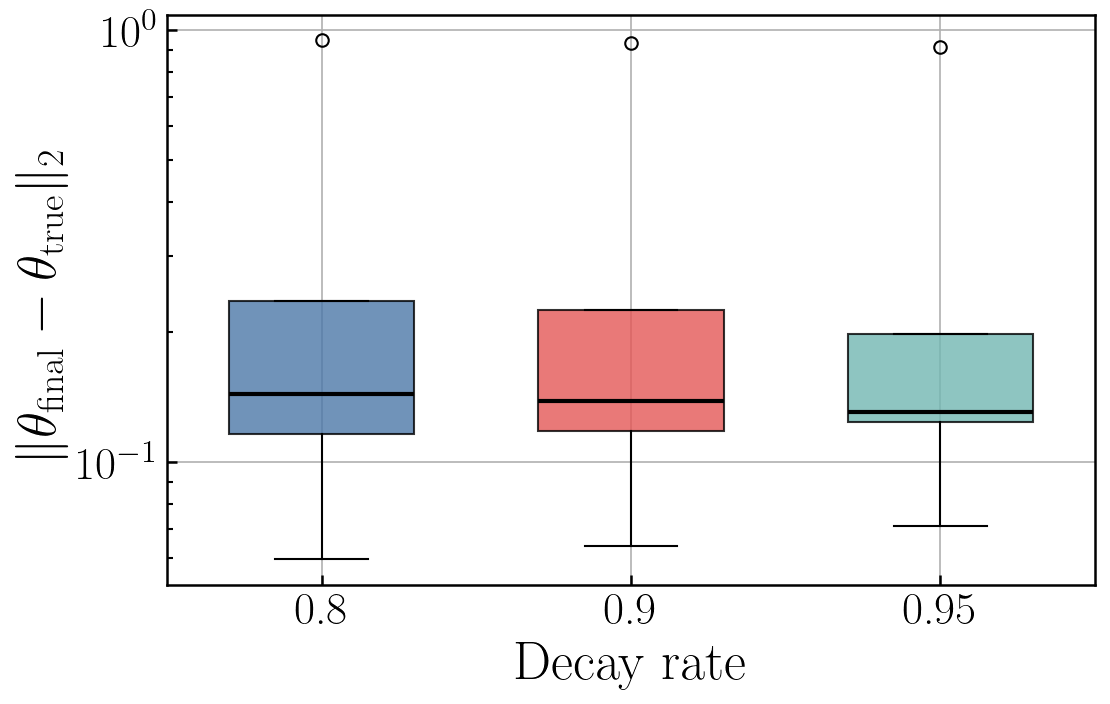

In [287]:
decay_files = list(gk_decay_dir.rglob("g_n_k_fixed*.npz"))
if decay_files:
    fig = make_gk_decay_boxplot(gk_decay_dir, DECAY_OUTPUT)
    print(f"Saved figure to {DECAY_OUTPUT}")
    display(fig)
else:
    print(f"Decay ablation figure not rendered because no files were found in {gk_decay_dir}.")


/var/folders/w6/g5h90fqj0lb6gbnsvjgzt5bw0000gn/T/ipykernel_96845/2361332185.py:201: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_mn_theta_error_boxplots.pdf


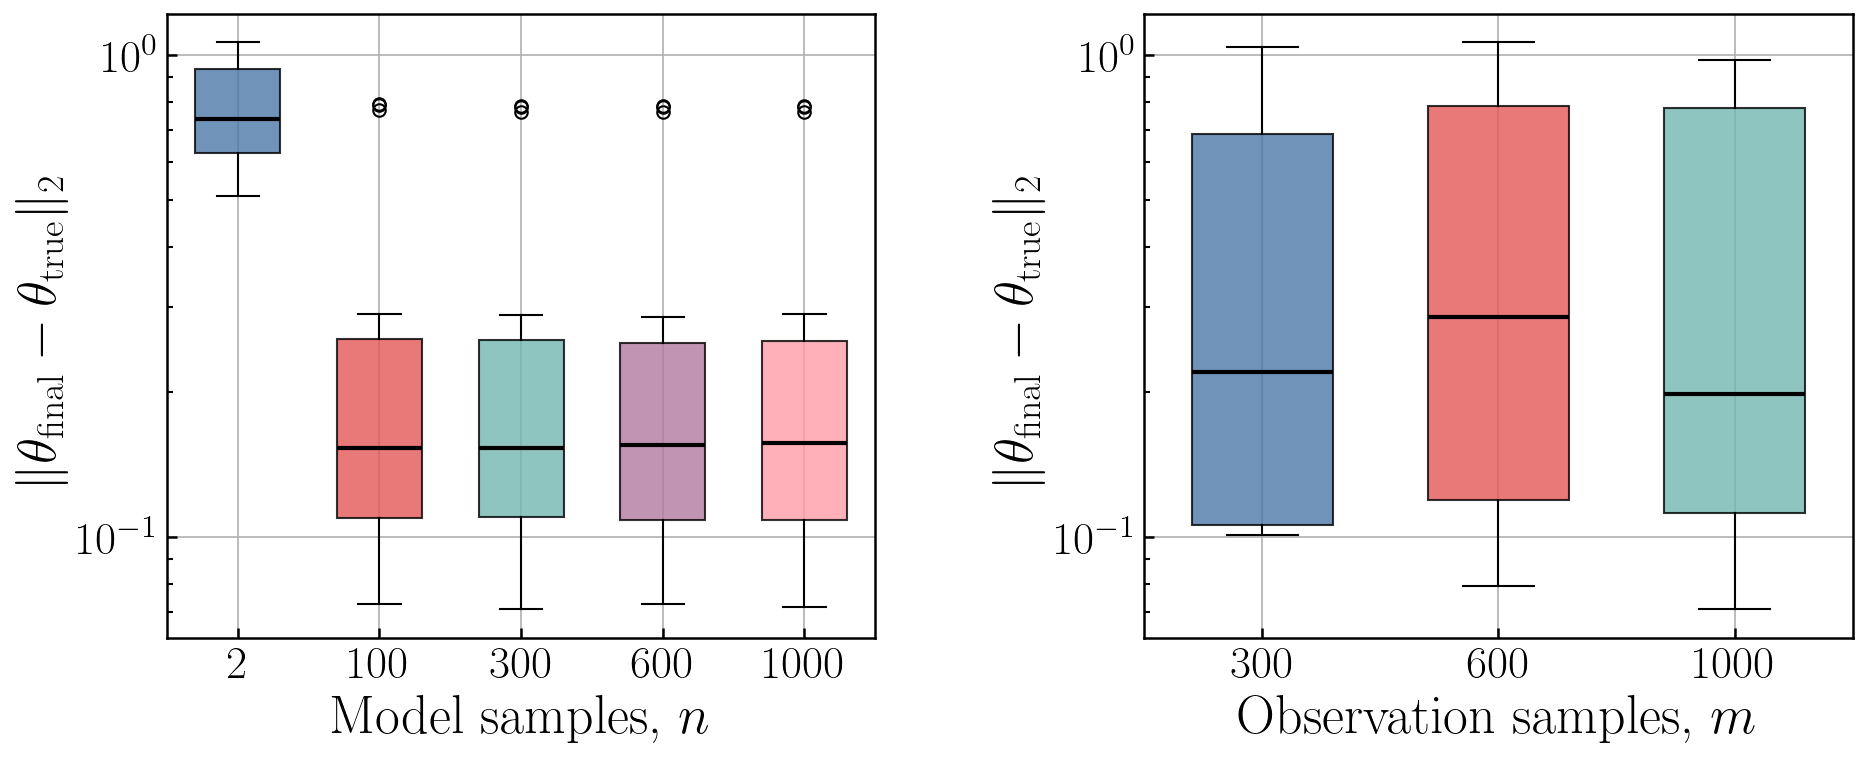

In [288]:
mn_files = list(gk_mn_dir.rglob("g_n_k_fixed*.npz"))
if mn_files:
    fig = make_gk_mn_boxplots(gk_mn_dir, MN_OUTPUT)
    print(f"Saved figure to {MN_OUTPUT}")
    display(fig)
else:
    print(f"m/n theta-error figure not rendered because no files were found in {gk_mn_dir}.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_cost_vs_mmd.pdf


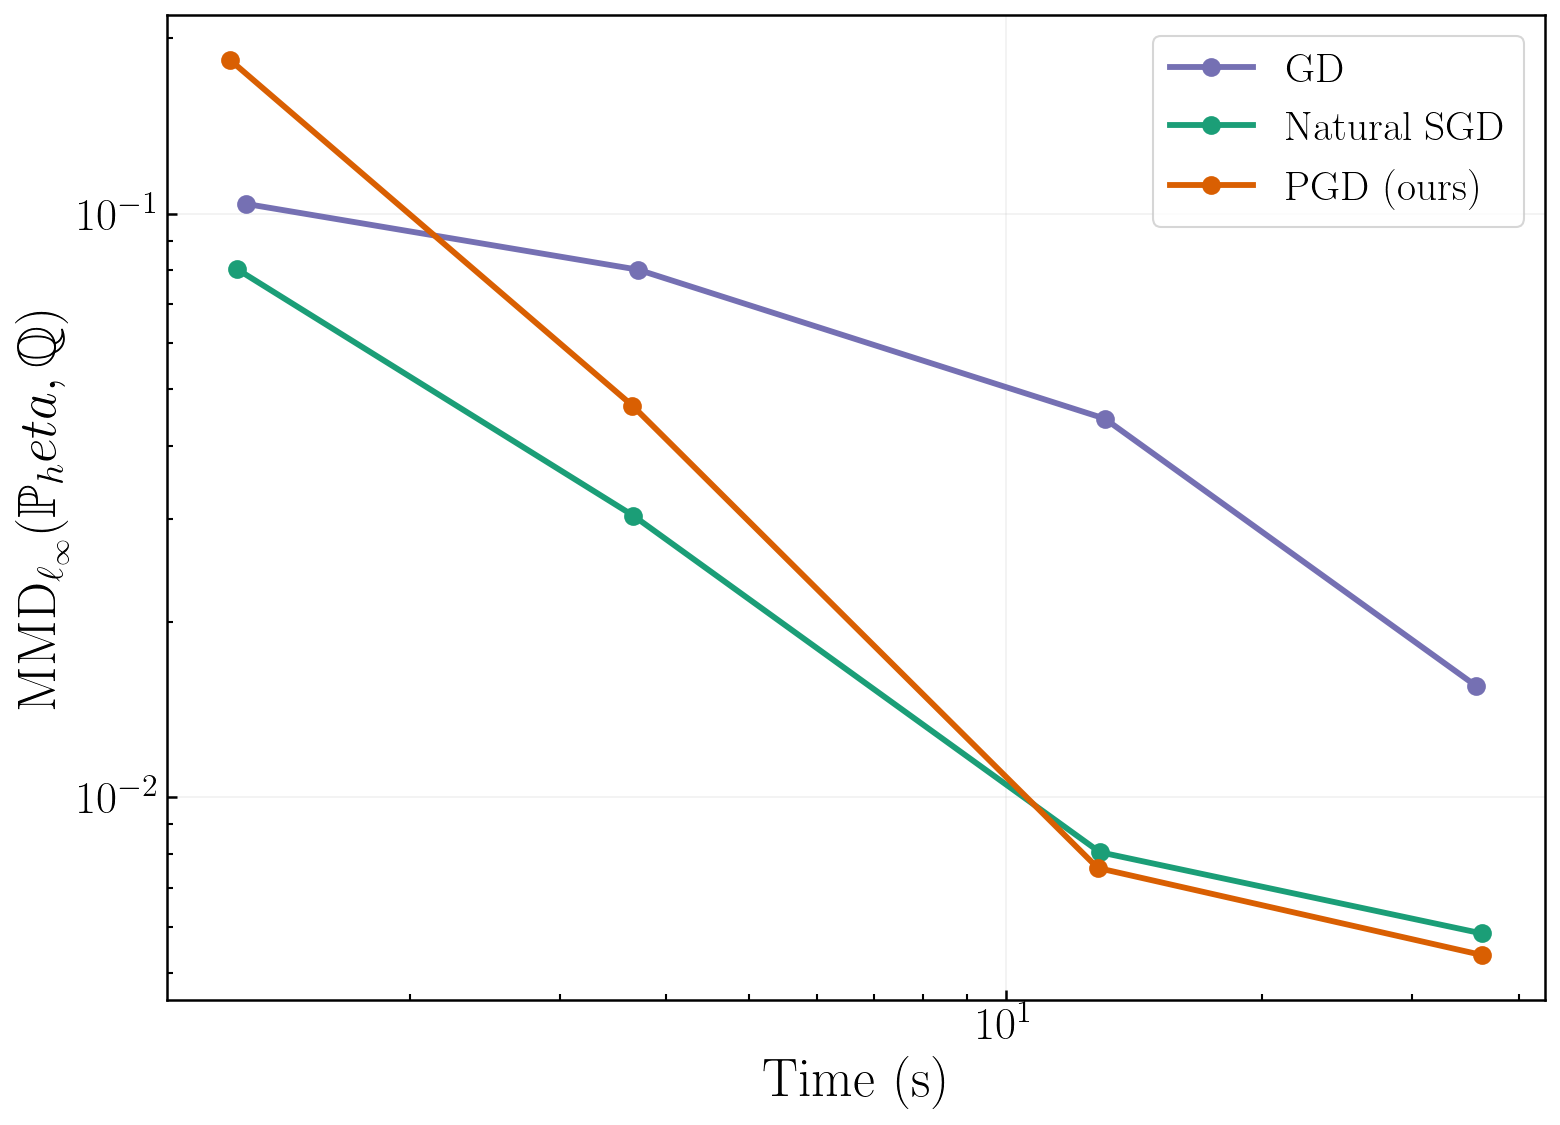

In [289]:
fixed600_time_paths = [
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_100.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_300.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_1000.npz",
    RESULTS_DIR / "g_n_k_theta0_3p500_2p000_0p600_m0p800_3000.npz",
]
fixed600_time_output = FIGURES_DIR / "gk_cost_vs_mmd.pdf"

missing_fixed600 = [path for path in fixed600_time_paths if not path.exists()]
if missing_fixed600:
    print(
        "Fixed-600 time plot not rendered because these input files are missing: "
        + ", ".join(str(path) for path in missing_fixed600)
    )
else:
    method_specs = [
        ("baseline", "GD", COLORS["sgd"]),
        ("natural", "Natural SGD", COLORS["natural"]),
        ("adaptive", "PGD (ours)", COLORS["pgd"]),
    ]

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(10.5, 7.6), dpi=150)

        for prefix, label, color in method_specs:
            times = []
            mmds = []

            for npz_path in fixed600_time_paths:
                data = _load_npz_dict(npz_path)
                times.append(float(np.asarray(data[f"{prefix}_elapsed_mean"], dtype=float)))
                mmds.append(np.sqrt(float(np.asarray(data[f"{prefix}_eval_mean"], dtype=float))))

            times = np.asarray(times, dtype=float)
            mmds = np.asarray(mmds, dtype=float)
            order = np.argsort(times)

            ax.plot(
                times[order],
                mmds[order],
                color=color,
                marker="o",
                linewidth=2.8,
                markersize=8,
                label=label,
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel(r"$\mathrm{MMD}_{\ell_\infty}(\mathbb{P}_	heta, \mathbb{Q})$")
        ax.grid(True, which="major", alpha=0.18, linewidth=0.8)
        ax.legend(loc="upper right", frameon=True)
        fig.tight_layout()
        fig.savefig(fixed600_time_output, bbox_inches="tight")
        print(f"Saved figure to {fixed600_time_output}")
        display(fig)


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_cross_method_comparison.pdf


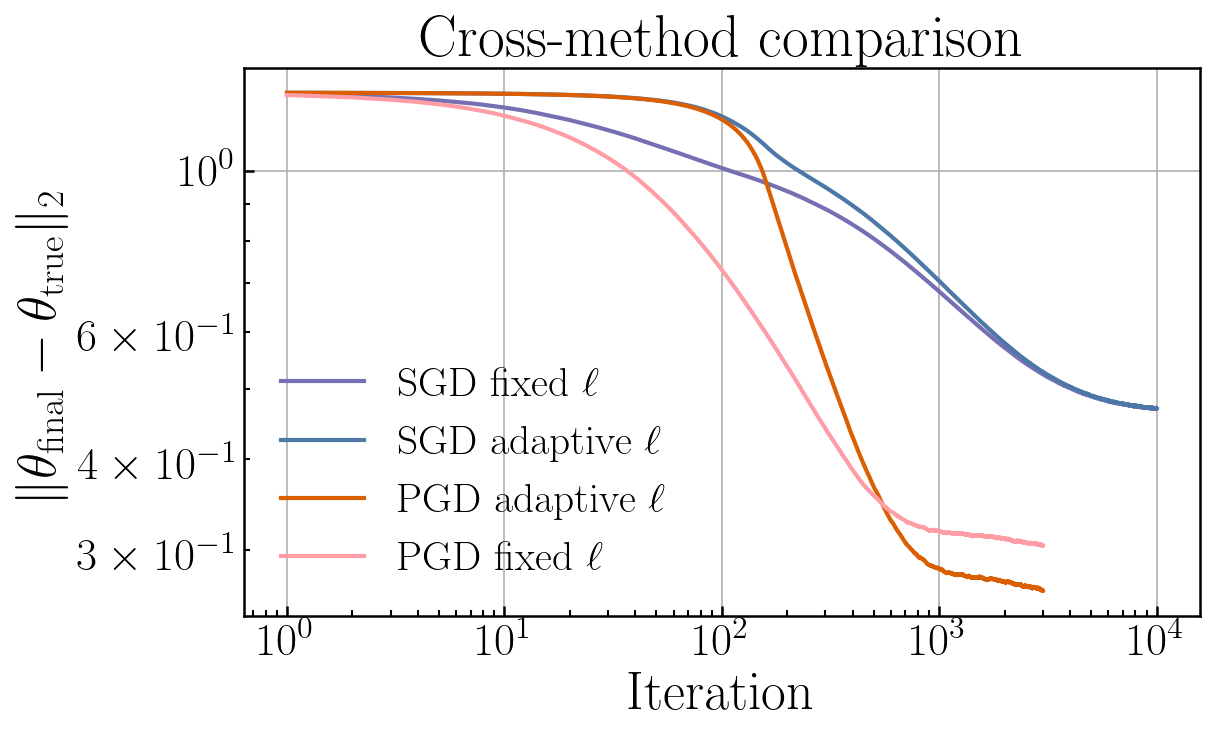

In [290]:
gk_compare_output = FIGURES_DIR / "gk_cross_method_comparison.pdf"
if gk_compare_npz.exists():
    try:
        fig = make_gk_cross_method_comparison(gk_compare_npz, gk_compare_output)
        print(f"Saved figure to {gk_compare_output}")
        display(fig)
    except KeyError as exc:
        print(f"Cross-method comparison not rendered: {exc}")
else:
    print(f"Cross-method comparison not rendered because {gk_compare_npz} is missing.")


Saved figure to /Users/sophiakang/Documents/GitHub/MDF_AL/figures/gk_lengthscale_ridge_ablation.pdf


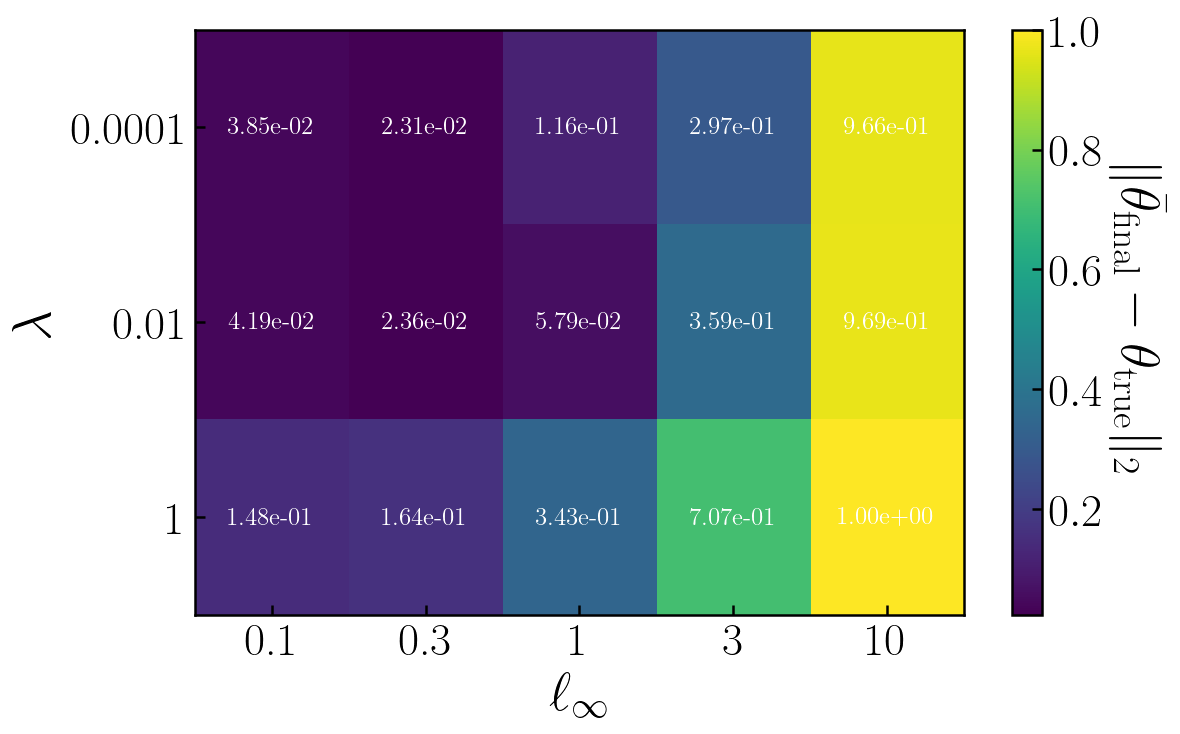

In [291]:
if gk_lengthscale_summary.exists():
    fig = make_gk_lengthscale_ridge_heatmap(gk_lengthscale_summary, LENGTHSCALE_OUTPUT)
    print(f"Saved figure to {LENGTHSCALE_OUTPUT}")
    display(fig)
else:
    print(f"Lengthscale/ridge figure not rendered because {gk_lengthscale_summary} is missing.")
